In [1]:
#import libs

import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import (Conv2D,
                          Flatten,
                          Dense)
from sklearn.metrics import classification_report

In [2]:
# Load images and resize
def load_images(directory, image_size=(128, 128)):
    X_values = []
    y_values = []
    folders = sorted([f for f in os.listdir(directory) if not f.startswith('.')])

    for i, each_folder in enumerate(folders):
        sub_path = os.path.join(directory, each_folder)
        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith('.'):
                full_path = os.path.join(sub_path, each_image)
                image = cv2.imread(full_path)
                image = cv2.resize(image, image_size)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # keep colour
                X_values.append(image)
                y_values.append(i)

    return np.array(X_values), np.array(y_values), folders


# --- Load Data ---
X_train_array, y_train, class_names = load_images('project_data/train', image_size=(128, 128))
X_val_array, y_val, _ = load_images('project_data/valid', image_size=(128, 128))
X_test_array, y_test, _ = load_images('project_data/test', image_size=(128, 128))

print(f"Training images: {X_train_array.shape}")
print(f"Validation images: {X_val_array.shape}")
print(f"Testing images: {X_test_array.shape}")
print(f"Number of classes: {len(class_names)}")

Training images: (7624, 128, 128, 3)
Validation images: (265, 128, 128, 3)
Testing images: (265, 128, 128, 3)
Number of classes: 53


In [3]:
# Load images and resize
def load_images(directory, image_size=(128, 128)):
    X_values = []
    y_values = []
    folders = sorted([f for f in os.listdir(directory) if not f.startswith('.')])

    for i, each_folder in enumerate(folders):
        sub_path = os.path.join(directory, each_folder)
        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith('.'):
                full_path = os.path.join(sub_path, each_image)
                image = cv2.imread(full_path)
                image = cv2.resize(image, image_size)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # keep colour
                X_values.append(image)
                y_values.append(i)

    return np.array(X_values), np.array(y_values), folders


# --- Load Data ---
X_train_array, y_train, class_names = load_images('project_data/train', image_size=(128, 128))
X_val_array, y_val, _ = load_images('project_data/valid', image_size=(128, 128))
X_test_array, y_test, _ = load_images('project_data/test', image_size=(128, 128))

print(f"Training images: {X_train_array.shape}")
print(f"Validation images: {X_val_array.shape}")
print(f"Testing images: {X_test_array.shape}")
print(f"Number of classes: {len(class_names)}")

Training images: (7624, 128, 128, 3)
Validation images: (265, 128, 128, 3)
Testing images: (265, 128, 128, 3)
Number of classes: 53


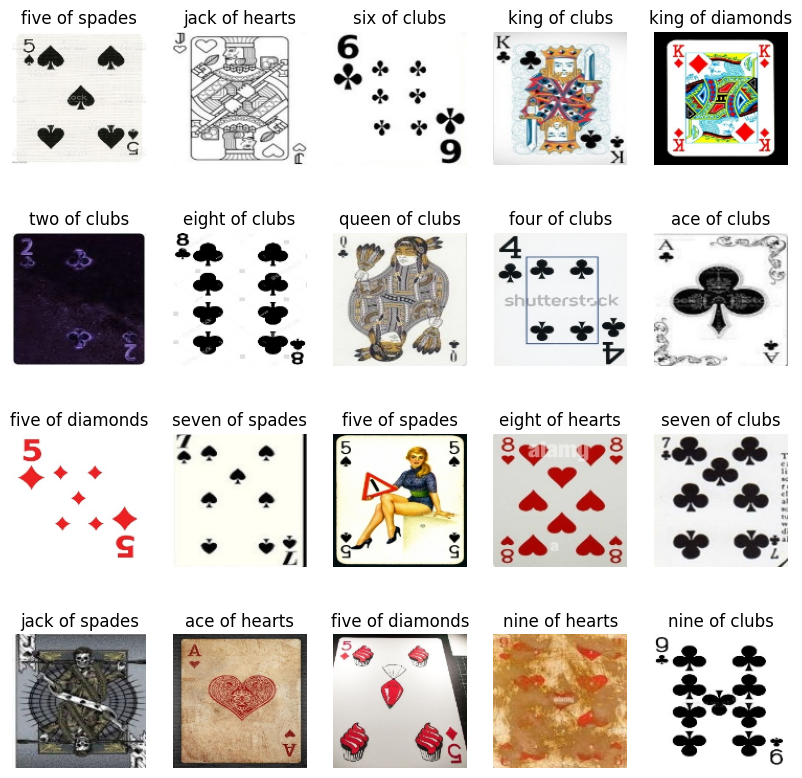

In [4]:
#Display 20 rand img trn images with proper labels

plt.figure(figsize=(10, 10))

for i in range(20):
    idx = random.randint(0, len(X_train_array) - 1)
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_array[idx])
    plt.title(class_names[y_train[idx]])
    plt.axis('off')

plt.show()


In [5]:
# Normalize 
X_train = X_train_array / 255.0
X_val = X_val_array / 255.0
X_test = X_test_array / 255.0

num_classes = len(class_names)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (7624, 128, 128, 3)
X_val shape: (265, 128, 128, 3)
X_test shape: (265, 128, 128, 3)
y_train shape: (7624,)
y_val shape: (265,)
y_test shape: (265,)


# Batch Normalization

In [ ]:
#build cnn model

# Part B - Improved CNN with Batch Normalization (Extracts features at increasing complexity)

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

improved_model = Sequential()

improved_model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2,2)))

improved_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2,2)))

improved_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2,2)))

improved_model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D((2,2)))

improved_model.add(Flatten())

improved_model.add(Dense(256, activation='relu'))
improved_model.add(BatchNormalization())

improved_model.add(Dense(128, activation='relu'))
improved_model.add(BatchNormalization())

improved_model.add(Dense(num_classes, activation='softmax'))

improved_model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 64, 64, 64)        256       
 chNormalization)                                                
                                                      

In [ ]:
# compile n train

improved_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_improved = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15
)


Epoch 1/15


239/239 [==============================] - 65s 231ms/step - loss: 2.6109 - accuracy: 0.3001 - val_loss: 3.4129 - val_accuracy: 0.1321
Epoch 2/15
239/239 [==============================] - 24s 100ms/step - loss: 1.7681 - accuracy: 0.5092 - val_loss: 1.8827 - val_accuracy: 0.5472
Epoch 3/15
239/239 [==============================] - 25s 105ms/step - loss: 1.2486 - accuracy: 0.6739 - val_loss: 1.1459 - val_accuracy: 0.6981
Epoch 4/15
239/239 [==============================] - 24s 98ms/step - loss: 0.8440 - accuracy: 0.7787 - val_loss: 0.8185 - val_accuracy: 0.7849
Epoch 5/15
239/239 [==============================] - 24s 99ms/step - loss: 0.5910 - accuracy: 0.8429 - val_loss: 1.5082 - val_accuracy: 0.6113
Epoch 6/15
239/239 [==============================] - 46s 193ms/step - loss: 0.4022 - accuracy: 0.8955 - val_loss: 0.6038 - val_accuracy: 0.8415
Epoch 7/15
239/239 [==============================] - 26s 110ms/step - loss: 0.1967 - accuracy: 0.9523 - val_loss: 0.6472 - val_a

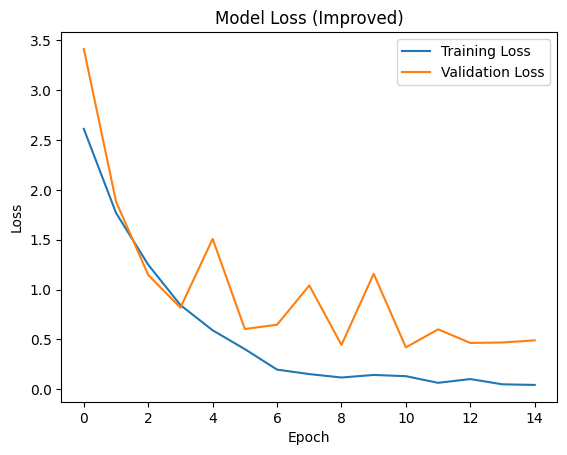

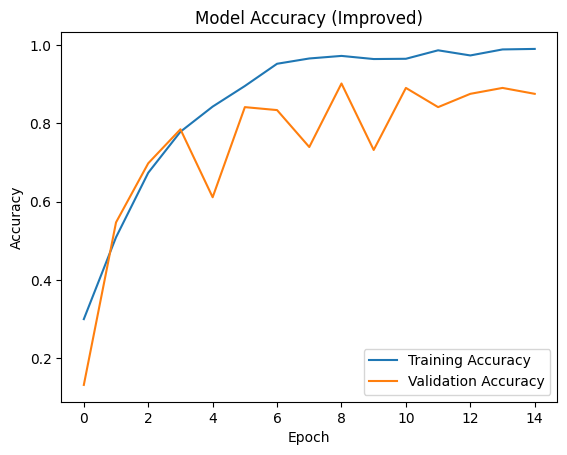

In [8]:
# visualization

import matplotlib.pyplot as plt

# loss
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Improved)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# accuracy
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (Improved)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [9]:
# evaluate

y_pred = improved_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=class_names))


9/9 [==============================] - 0s 31ms/step
                   precision    recall  f1-score   support

     ace of clubs       1.00      1.00      1.00         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       0.83      1.00      0.91         5
    ace of spades       1.00      1.00      1.00         5
   eight of clubs       0.71      1.00      0.83         5
eight of diamonds       0.83      1.00      0.91         5
  eight of hearts       0.71      1.00      0.83         5
  eight of spades       0.83      1.00      0.91         5
    five of clubs       1.00      0.80      0.89         5
 five of diamonds       1.00      0.80      0.89         5
   five of hearts       1.00      1.00      1.00         5
   five of spades       1.00      0.80      0.89         5
    four of clubs       1.00      1.00      1.00         5
 four of diamonds       1.00      1.00      1.00         5
   four of hearts       1.00      0.80      0.89         5
   

# Data Augmentation

In [10]:
#Create a tool that modifies my images

from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10, # rotate
    width_shift_range=0.05, # move image up down left right
    height_shift_range=0.05, #
    zoom_range=0.05 # zoom in n out
)

datagen.fit(X_train)

In [ ]:
#Building of CNN model with data augmentation

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

improved_model_aug = Sequential()

improved_model_aug.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)))
improved_model_aug.add(MaxPooling2D((2,2)))

improved_model_aug.add(Conv2D(64, (3,3), activation='relu', padding='same'))
improved_model_aug.add(MaxPooling2D((2,2)))

improved_model_aug.add(Conv2D(128, (3,3), activation='relu', padding='same'))
improved_model_aug.add(MaxPooling2D((2,2)))

improved_model_aug.add(Conv2D(256, (3,3), activation='relu', padding='same'))
improved_model_aug.add(MaxPooling2D((2,2)))

improved_model_aug.add(Flatten())

improved_model_aug.add(Dense(256, activation='relu'))

improved_model_aug.add(Dense(128, activation='relu'))

improved_model_aug.add(Dense(num_classes, activation='softmax'))

improved_model_aug.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 64, 64, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 32, 32, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 16, 16, 128)      

In [12]:
#Prepare model for training

improved_model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# Train model using augmented images n not normal images

history_aug = improved_model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=15
)

Epoch 1/15
239/239 [==============================] - 29s 119ms/step - loss: 3.3138 - accuracy: 0.1406 - val_loss: 1.8933 - val_accuracy: 0.3585
Epoch 2/15
239/239 [==============================] - 45s 186ms/step - loss: 2.0613 - accuracy: 0.3851 - val_loss: 1.2825 - val_accuracy: 0.5887
Epoch 3/15
239/239 [==============================] - 38s 160ms/step - loss: 1.5727 - accuracy: 0.5584 - val_loss: 0.8469 - val_accuracy: 0.7585
Epoch 4/15
239/239 [==============================] - 28s 116ms/step - loss: 1.2582 - accuracy: 0.6447 - val_loss: 0.8174 - val_accuracy: 0.7811
Epoch 5/15
239/239 [==============================] - 25s 103ms/step - loss: 1.0934 - accuracy: 0.6860 - val_loss: 0.7484 - val_accuracy: 0.8075
Epoch 6/15
239/239 [==============================] - 28s 117ms/step - loss: 0.9538 - accuracy: 0.7272 - val_loss: 0.5849 - val_accuracy: 0.8151
Epoch 7/15
239/239 [==============================] - 25s 103ms/step - loss: 0.8229 - accuracy: 0.7591 - val_loss: 0.5923 - val_ac

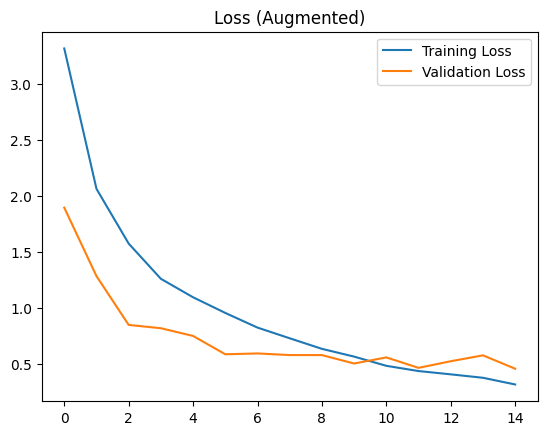

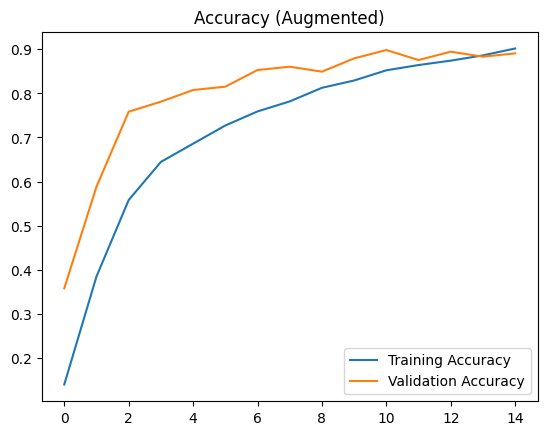

In [14]:
# Visualisation

import matplotlib.pyplot as plt

# loss
plt.plot(history_aug.history['loss'], label='Training Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss (Augmented)')
plt.show()

# accuracy
plt.plot(history_aug.history['accuracy'], label='Training Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy (Augmented)')
plt.show()

In [15]:
# Run evaluation

y_pred_aug = improved_model_aug.predict(X_test)
y_pred_classes_aug = np.argmax(y_pred_aug, axis=1)

print(classification_report(y_test, y_pred_classes_aug, target_names=class_names))

9/9 [==============================] - 0s 19ms/step
                   precision    recall  f1-score   support

     ace of clubs       0.83      1.00      0.91         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       1.00      1.00      1.00         5
    ace of spades       0.83      1.00      0.91         5
   eight of clubs       0.62      1.00      0.77         5
eight of diamonds       0.71      1.00      0.83         5
  eight of hearts       1.00      0.80      0.89         5
  eight of spades       1.00      1.00      1.00         5
    five of clubs       1.00      0.60      0.75         5
 five of diamonds       1.00      0.60      0.75         5
   five of hearts       1.00      1.00      1.00         5
   five of spades       1.00      1.00      1.00         5
    four of clubs       1.00      0.60      0.75         5
 four of diamonds       0.71      1.00      0.83         5
   four of hearts       0.83      1.00      0.91         5
   

## Ensemble Method

In [16]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Get predictions from both models
prediction_1 = improved_model.predict(X_test)
prediction_2 = improved_model_aug.predict(X_test)

# Average predictions
ensemble_pred = (prediction_1 + prediction_2) / 2

# Convert to class labels
ensemble_classes = np.argmax(ensemble_pred, axis=1)

# Evaluate ensemble
print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_classes))
print(classification_report(y_test, ensemble_classes))

9/9 [==============================] - 0s 21ms/step
Ensemble Accuracy: 0.9018867924528302
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       0.83      1.00      0.91         5
           4       0.71      1.00      0.83         5
           5       0.83      1.00      0.91         5
           6       0.83      1.00      0.91         5
           7       0.83      1.00      0.91         5
           8       1.00      0.80      0.89         5
           9       1.00      0.80      0.89         5
          10       1.00      1.00      1.00         5
          11       1.00      0.80      0.89         5
          12       1.00      0.80      0.89         5
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00  

# Transfer Learning with MobileNetV2

### Preprocess Data

In [17]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
 
X_train_mobile = preprocess_input(X_train_array.astype("float32"))
X_val_mobile   = preprocess_input(X_val_array.astype("float32"))
X_test_mobile  = preprocess_input(X_test_array.astype("float32"))

### Building Of The Model

In [18]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

### Load MobileNetV2 without original classifier (keeps the convolutional base only so i can attach my own custom classifier for my dataset)

In [19]:
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze pretrained weights so i can add in my own classifiers

### Add a new classifier on top

In [20]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation="softmax")(x)
 
transfer_model = Model(base_model.input, outputs)
transfer_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 64, 64, 32)           864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 64, 64, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 64, 64, 32)           0         ['bn_Conv1[0][0]']        

### Train

In [21]:
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
 
history_transfer = transfer_model.fit(
    X_train_mobile, y_train,
    validation_data=(X_val_mobile, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
239/239 [==============================] - 12s 45ms/step - loss: 3.0555 - accuracy: 0.1897 - val_loss: 1.9639 - val_accuracy: 0.4075
Epoch 2/15
239/239 [==============================] - 12s 52ms/step - loss: 2.1385 - accuracy: 0.3800 - val_loss: 1.6050 - val_accuracy: 0.5170
Epoch 3/15
239/239 [==============================] - 13s 53ms/step - loss: 1.7868 - accuracy: 0.4790 - val_loss: 1.4833 - val_accuracy: 0.5245
Epoch 4/15
239/239 [==============================] - 13s 55ms/step - loss: 1.5387 - accuracy: 0.5404 - val_loss: 1.3983 - val_accuracy: 0.5434
Epoch 5/15
239/239 [==============================] - 13s 55ms/step - loss: 1.3454 - accuracy: 0.5959 - val_loss: 1.3440 - val_accuracy: 0.5811
Epoch 6/15
239/239 [==============================] - 13s 55ms/step - loss: 1.1913 - accuracy: 0.6358 - val_loss: 1.3509 - val_accuracy: 0.5660
Epoch 7/15
239/239 [==============================] - 14s 58ms/step - loss: 1.0524 - accuracy: 0.6712 - val_loss: 1.3340 - val_accuracy:

### Visualize

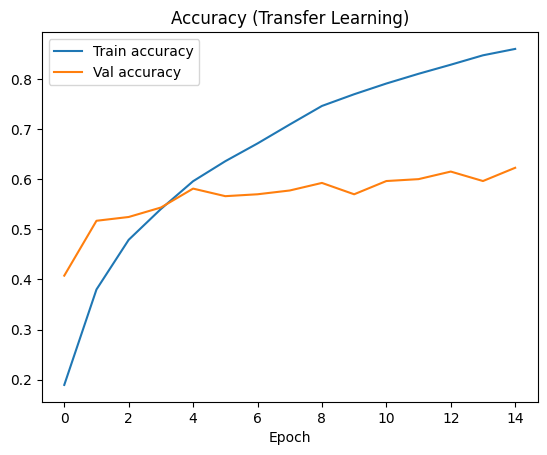

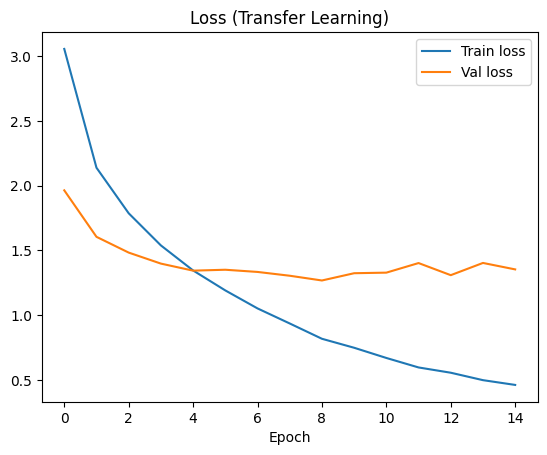

In [22]:
import matplotlib.pyplot as plt
 
plt.plot(history_transfer.history["accuracy"],     label="Train accuracy")
plt.plot(history_transfer.history["val_accuracy"], label="Val accuracy")
plt.title("Accuracy (Transfer Learning)")
plt.xlabel("Epoch")
plt.legend()
plt.show()
 
plt.plot(history_transfer.history["loss"],     label="Train loss")
plt.plot(history_transfer.history["val_loss"], label="Val loss")
plt.title("Loss (Transfer Learning)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

### Evaluate

In [23]:
from sklearn.metrics import classification_report
import numpy as np
 
y_pred = np.argmax(transfer_model.predict(X_test_mobile), axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

9/9 [==============================] - 1s 38ms/step
                   precision    recall  f1-score   support

     ace of clubs       0.62      1.00      0.77         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       0.50      1.00      0.67         5
    ace of spades       1.00      1.00      1.00         5
   eight of clubs       0.25      0.40      0.31         5
eight of diamonds       0.60      0.60      0.60         5
  eight of hearts       0.80      0.80      0.80         5
  eight of spades       1.00      0.40      0.57         5
    five of clubs       0.33      0.60      0.43         5
 five of diamonds       0.80      0.80      0.80         5
   five of hearts       0.50      0.40      0.44         5
   five of spades       0.57      0.80      0.67         5
    four of clubs       1.00      0.20      0.33         5
 four of diamonds       0.80      0.80      0.80         5
   four of hearts       1.00      0.60      0.75         5
   

c:\Users\jqjur\miniconda3\envs\CVE\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jqjur\miniconda3\envs\CVE\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jqjur\miniconda3\envs\CVE\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
